# CHUQ corpus: proton elastic

The CHUQ corpus is a reconstruction of the experimental data used in the CH89 global optical potential analysis, assembled from EXFOR by the supplement's authors and tabulated in Supplemental Material B.

Proton differential elastic scattering cross sections, stored as a ratio to Rutherford against CM scattering angle. EXFOR reports some of these data sets as ratios and others as absolute cross sections; the absolute ones are divided by the Rutherford cross section so the sector is uniform.

The subentries and scattering energies below are transcribed from the supplement's
tables into `spec/chuq_proton_elastic.csv`. Every row must be accounted for: it either
produces data, or it is listed in `spec/known_missing.csv` with a reason. Uncertainties
are assigned by the supplement's preference rule (`nn_corpora.errors`), and the
corrections its Comments describe are applied from `nn_corpora.overrides`.

In [1]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt

import pandas as pd

from nn_corpora import corpus, plotting, report, spec

pd.set_option("display.max_rows", 200)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## The specification

In [2]:
rows = spec.load_sector('chuq', 'proton_elastic')
print(f"{len(rows)} rows, {len({r.subentry for r in rows if r.in_exfor})} distinct subentries")
pd.DataFrame([vars(r) for r in rows]).head(15)

85 rows, 85 distinct subentries


,corpus,sector,projectile,target_A,target_Z,target_label,energy_mev,energy_hi_mev,subentry,pointer,pdf_page
0,chuq,proton_elastic,proton,40,20,40Ca,40.0,None,O0328003,,22
1,chuq,proton_elastic,proton,40,20,40Ca,65.0,None,O0032002,S,22
2,chuq,proton_elastic,proton,44,20,44Ca,65.0,None,O0032056,S,22
3,chuq,proton_elastic,proton,46,22,46Ti,65.0,None,O0032058,S,22
4,chuq,proton_elastic,proton,48,20,48Ca,65.0,None,O0032057,S,22
5,chuq,proton_elastic,proton,48,22,48Ti,16.0,None,C0893004,,22
6,chuq,proton_elastic,proton,48,22,48Ti,65.0,None,O0032059,S,22
7,chuq,proton_elastic,proton,50,22,50Ti,16.0,None,C0893006,,22
8,chuq,proton_elastic,proton,50,22,50Ti,65.0,None,O0032060,S,22
9,chuq,proton_elastic,proton,54,26,54Fe,16.0,None,C0893008,,22


## Retrieve and clean

`corpus.curate` retrieves each entry, matches measurements back to the rows that asked
for them, applies the documented corrections, and homogenises units and frames.

In [3]:
result = corpus.curate('chuq', 'proton_elastic')
print(result.summary())

chuq/proton_elastic
  spec rows              85
  ... marked absent      0
  ... resolved           79 / 85 (92.9%)
  measurements           79
  data points            2497
  EXFOR entries          8
  unresolved by category
    x4i3-parse-failure       3
    subentry-withdrawn       3
  serialized             79 measurements, 2497 points


## Rows that did not resolve

Every row listed here must appear in `spec/known_missing.csv`, or the write below will
fail. The categories are: `absent-from-exfor` (the supplement itself marks the row as
not locatable), `x4i3-parse-failure` (the entry is in EXFOR but x4i3 cannot read it),
`subentry-withdrawn` (EXFOR has renumbered or removed the subentry since the supplement
was written), `energy-not-found`, and `uncertainty-unresolved`.

In [4]:
print(report.unresolved_table(result.data))

54Fe     40.000 O0162023  [x4i3-parse-failure] uncertainty unresolved (entry-unavailable): entry O0162 is not in the x4i3 index; it is most likely one of the entries x4i3 fails to parse
58Ni     40.000 O0162025  [x4i3-parse-failure] uncertainty unresolved (entry-unavailable): entry O0162 is not in the x4i3 index; it is most likely one of the entries x4i3 fails to parse
60Ni     40.000 O0162027  [x4i3-parse-failure] uncertainty unresolved (entry-unavailable): entry O0162 is not in the x4i3 index; it is most likely one of the entries x4i3 fails to parse
40Ca     40.000 O0328003  [subentry-withdrawn] subentry not present in entry O0328 for this quantity
90Zr     40.000 O0328006  [subentry-withdrawn] subentry not present in entry O0328 for this quantity
208Pb    40.000 O0328008  [subentry-withdrawn] subentry not present in entry O0328 for this quantity


## Uncertainty audit

Data sets with missing uncertainties are dropped during munging, following the
supplement's removal of any data set lacking a necessary feature. This lists anything
that survived but still looks suspicious.

In [5]:
flags = plotting.check_uncertainties(result)
print("\n".join(flags) if flags else "every measurement carries uncertainties")

every measurement carries uncertainties


## Inspect

Outliers here are found by eye. A mistranscribed point shows up as a single datum an
order of magnitude away from its neighbours; a badly normalised data set shows up as a
whole curve offset from others at the same energy.

... 40 further targets not plotted


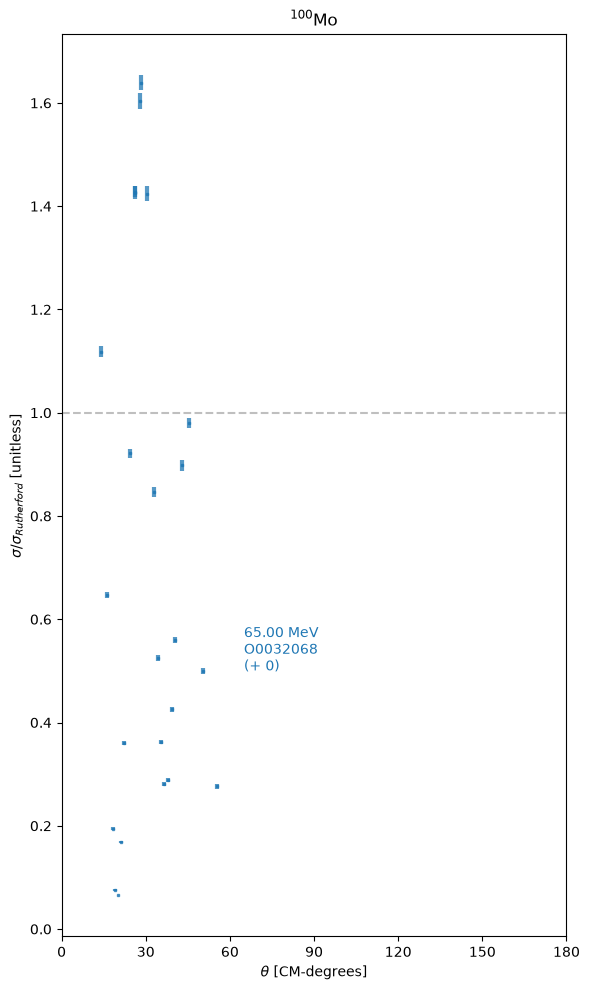

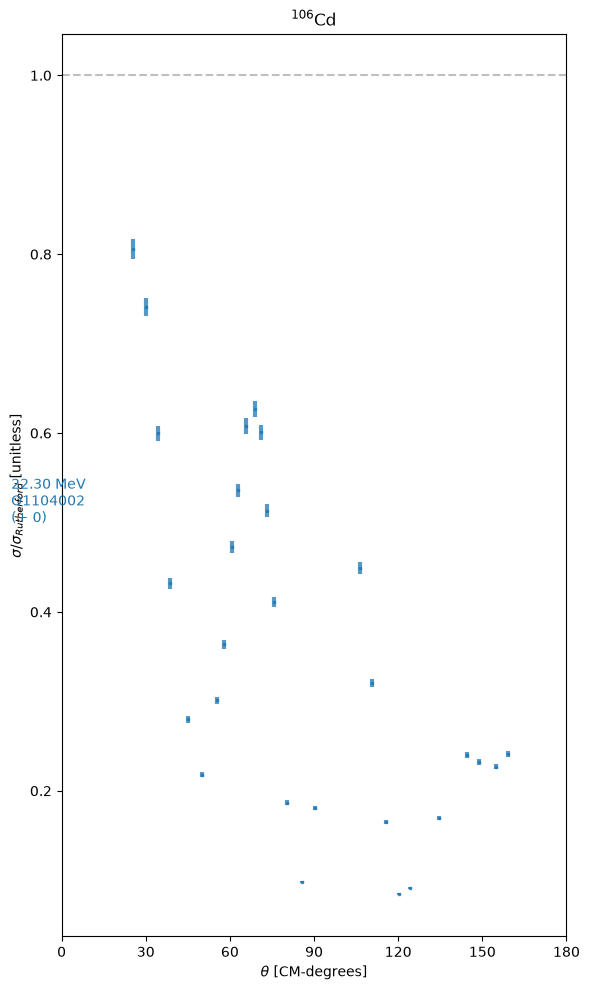

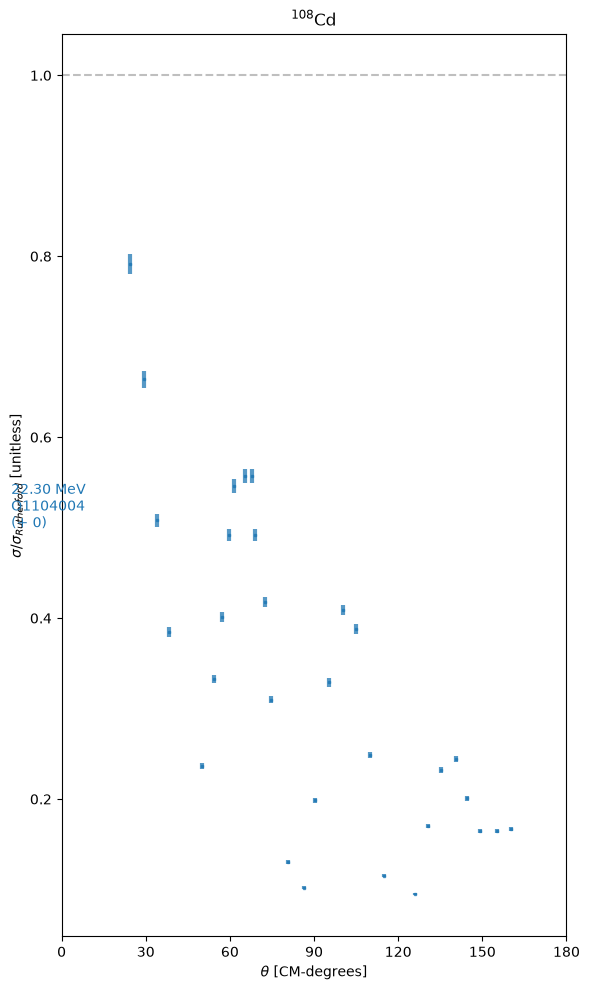

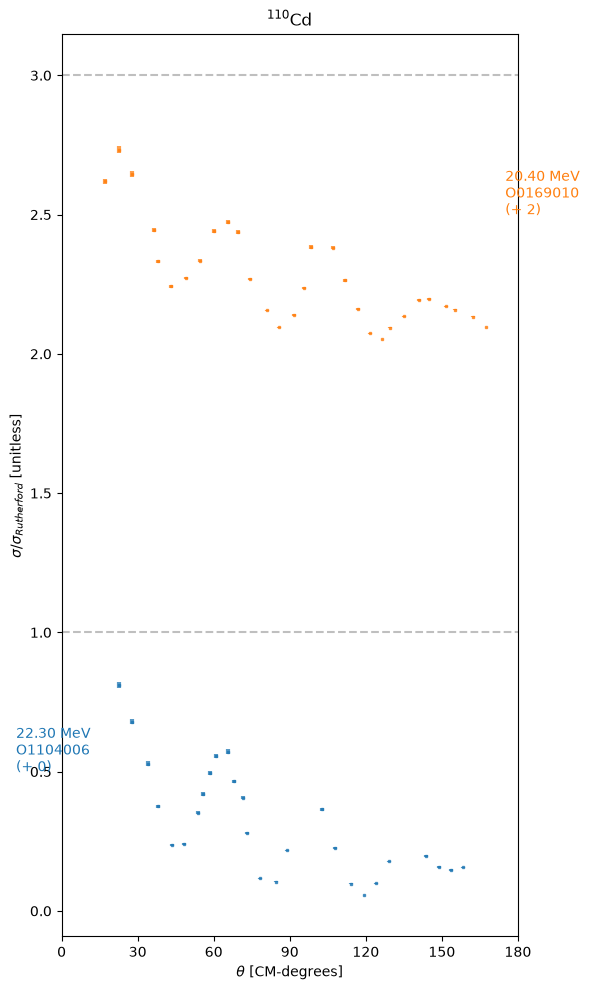

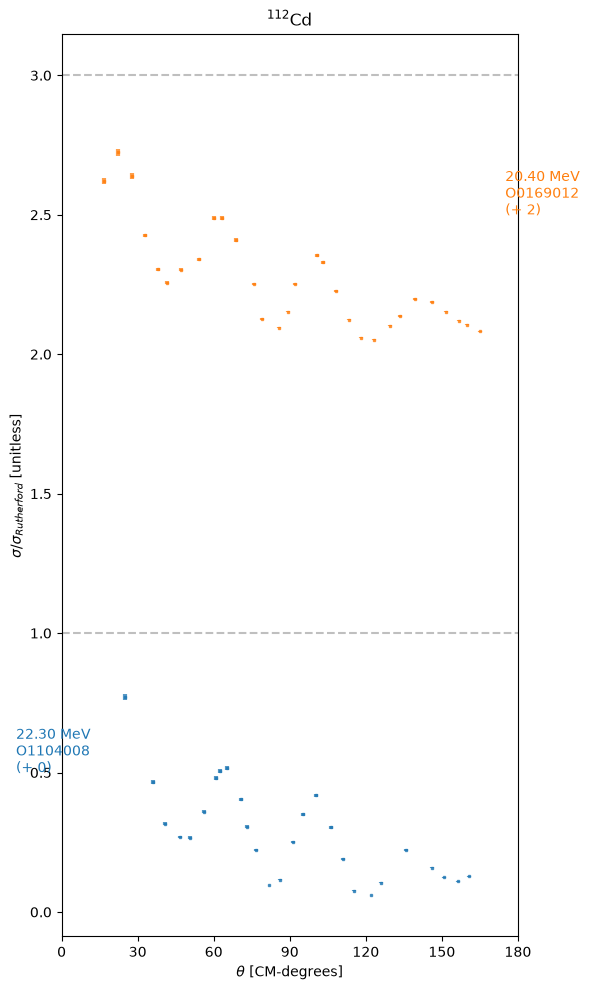

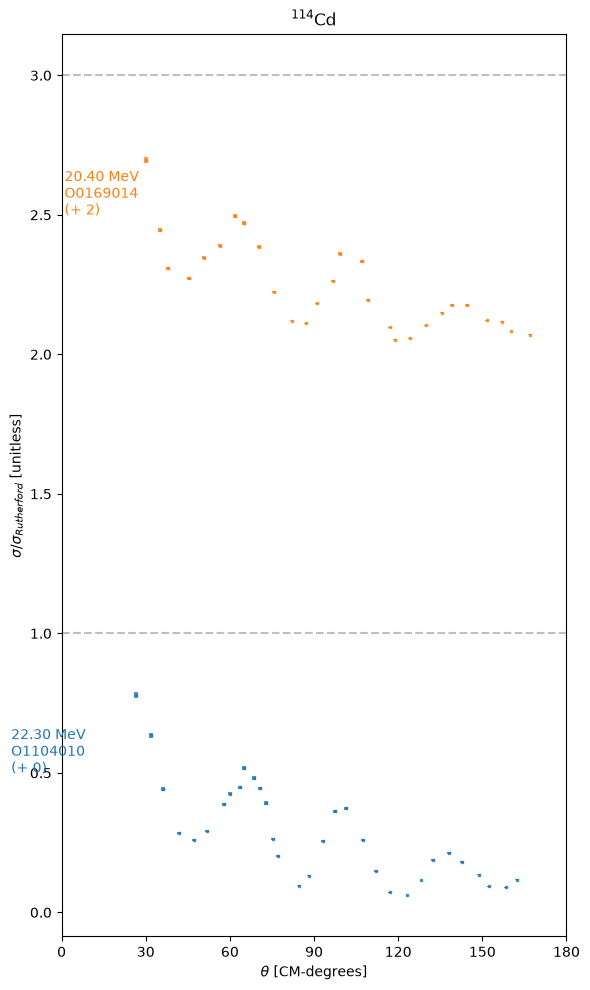

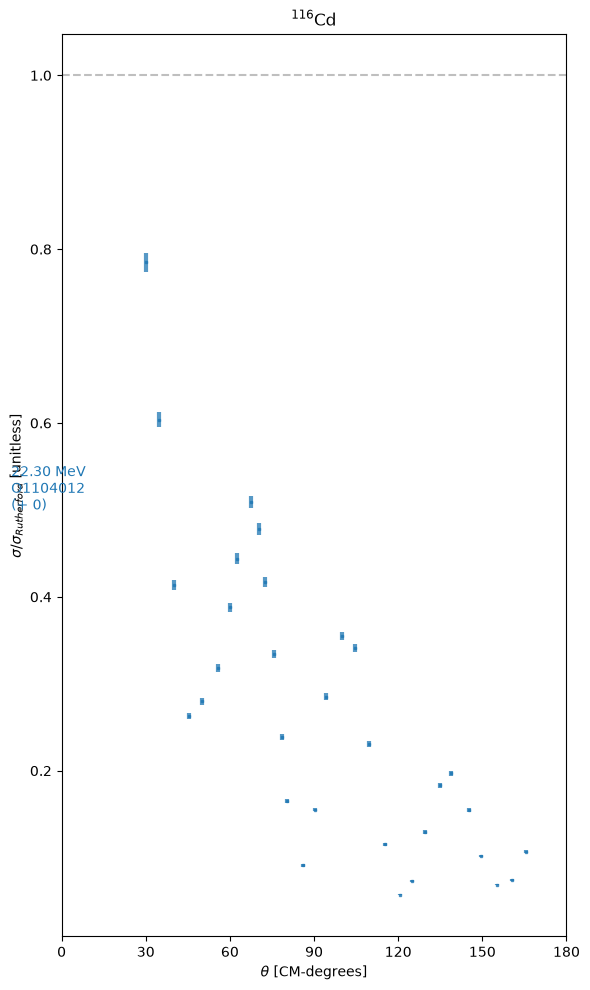

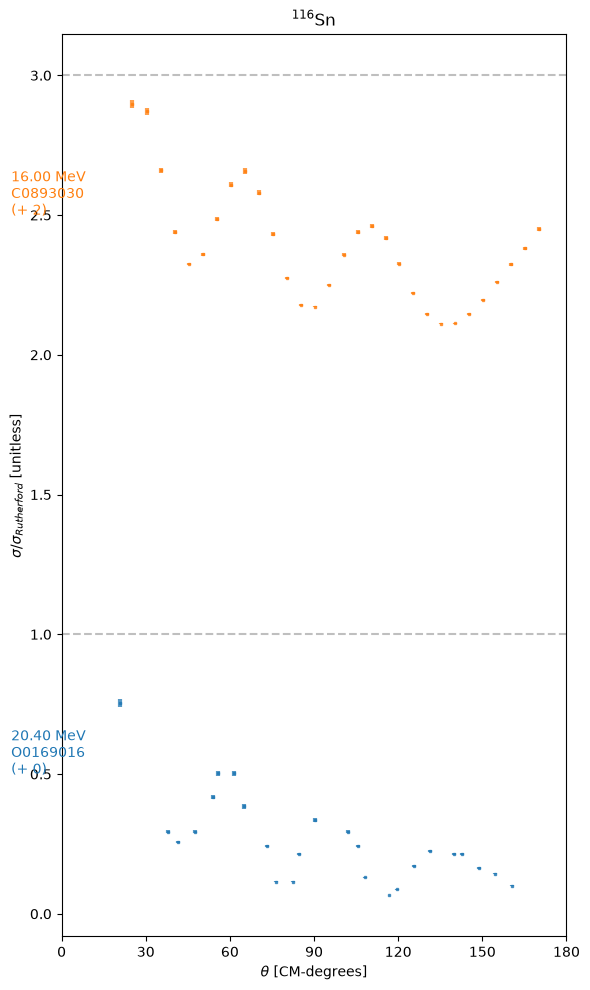

In [6]:
plotting.plot_sector(result, max_targets=8)
plt.show()

## Write

`corpus.write` re-checks coverage against the allowlist before writing, so a data set
that silently disappears from EXFOR fails here rather than passing unnoticed.

In [7]:
corpus.write(result)
print(f"wrote {len(result.records)} measurements to data/{result.corpus}/{result.sector}/")

wrote 79 measurements to data/chuq/proton_elastic/
